## Testing the model wiht protein information

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import torch
import networkx as nx

#os.chdir("/research/groups/bioinformaticians/internship/hhuotari/DIISCO/Updated_DIISCO")
# import constants as diisco.constants
# import gaussian_process
# import math_ops
# import names
# import prior_f_model
# import priot_w_model
# import utils
import diisco


In [3]:
#os.chdir("/research/groups/bioinformaticians/internship/hhuotari")
         
prior = pd.read_csv('data/prior_EG11_intersect.csv')
P_t = np.load('data/real_protein_values.npy')
K_t = pd.read_csv('data/W_EG11_16.csv')

In [4]:
# from scipy.interpolate import CubicSpline

W = K_t.set_index('Timepoint')
# time_p = np.linspace(W.index.min(), W.index.max(), 20)

# inter = pd.DataFrame(index=time_p, columns=W.columns)

# for col in W.columns:
#     cs = CubicSpline(W.index, W[col])
#     inter[col] = cs(time_p)

In [ ]:
P_t1 = P_t[0]
P_t2 = P_t[1]
P_t1 = np.delete(P_t1,-3,0)
P_t1 = np.delete(P_t1,-3,1)
P_t2 = np.delete(P_t2,-3,0)
P_t2 = np.delete(P_t2,-3,1)
P_t = np.array([P_t1, P_t2])
print(P_t.shape)
print(P_t)

(2, 10, 10)


In [6]:
celltypes = W.columns
celltypes  

Index(['B', 'CD4 Memory T', 'CD8 Memory T', 'Early Lymphoid', 'HSC MPP',
       'Monocyte', 'NK', 'Naive T', 'Pre-B', 'Pro-B'],
      dtype='object')

In [6]:
W

,B,CD4 Memory T,CD8 Memory T,Early Lymphoid,HSC MPP,Monocyte,NK,Naive T,Pre-B,Pro-B
Timepoint,,,,,,,,,,
0,0.012937,0.014230,0.041397,0.005175,0.002587,0.002587,0.041397,0.031048,0.099612,0.737387
15,0.152257,0.036215,0.234634,0.000000,0.000000,0.001785,0.509309,0.051262,0.001020,0.004336


Text(0, 0.5, 'Proportion')

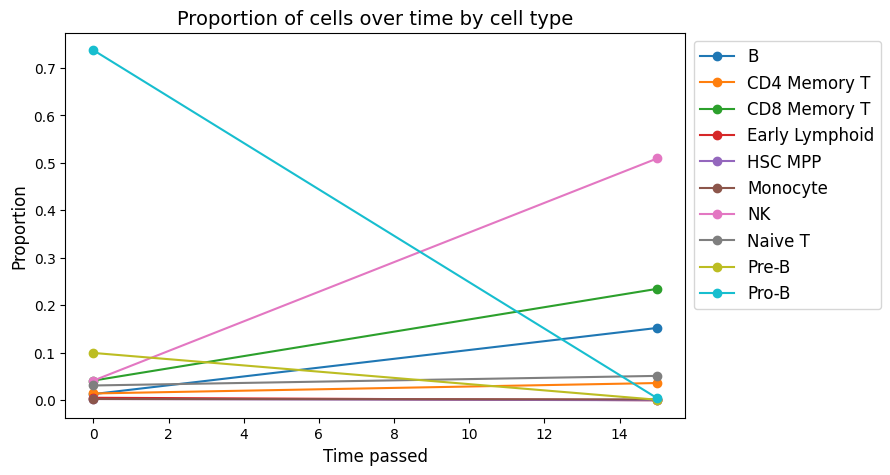

In [7]:
plt.figure(figsize=(8, 5))
for cell_type in celltypes:
    plt.plot(W[cell_type], marker='o', label=cell_type)
plt.legend( fontsize=12, bbox_to_anchor=(1, 1))
plt.title('Proportion of cells over time by cell type', fontsize=14)
plt.xlabel('Time passed', fontsize=12)
plt.ylabel('Proportion', fontsize=12)

In [8]:
P_t

array([[[ 0.        ,  0.        ,  0.45073923,  0.        ,
          0.        ,  0.        ,  0.18695996,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.30658632,  0.25598533,  0.        ,
          0.        ,  0.        ,  0.09298481,  0.        ,
         -0.06635318,  0.0928933 ],
        [ 0.        ,  0.33628682,  0.28495586,  0.        ,
          0.        ,  0.        ,  0.13774899,  0.        ,
         -0.03280655,  0.13934525],
        [ 0.        ,  0.        ,  0.48861509,  0.        ,
          0.        ,  0.        , -0.91782942,  0.        ,
          0.        , -0.43499413],
        [ 0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.32969021,  0.46502446,  0. 

In [9]:
P_dg = P_t[0,:,:]
p_d15 = P_t[1,:,:]

[Text(0, 0.5, 'B'),
 Text(0, 1.5, 'CD4 Memory T'),
 Text(0, 2.5, 'CD8 Memory T'),
 Text(0, 3.5, 'Early Lymphoid'),
 Text(0, 4.5, 'HSC MPP'),
 Text(0, 5.5, 'Monocyte'),
 Text(0, 6.5, 'NK'),
 Text(0, 7.5, 'Naive T'),
 Text(0, 8.5, 'Pre-B'),
 Text(0, 9.5, 'Pro-B')]

<Figure size 900x600 with 0 Axes>

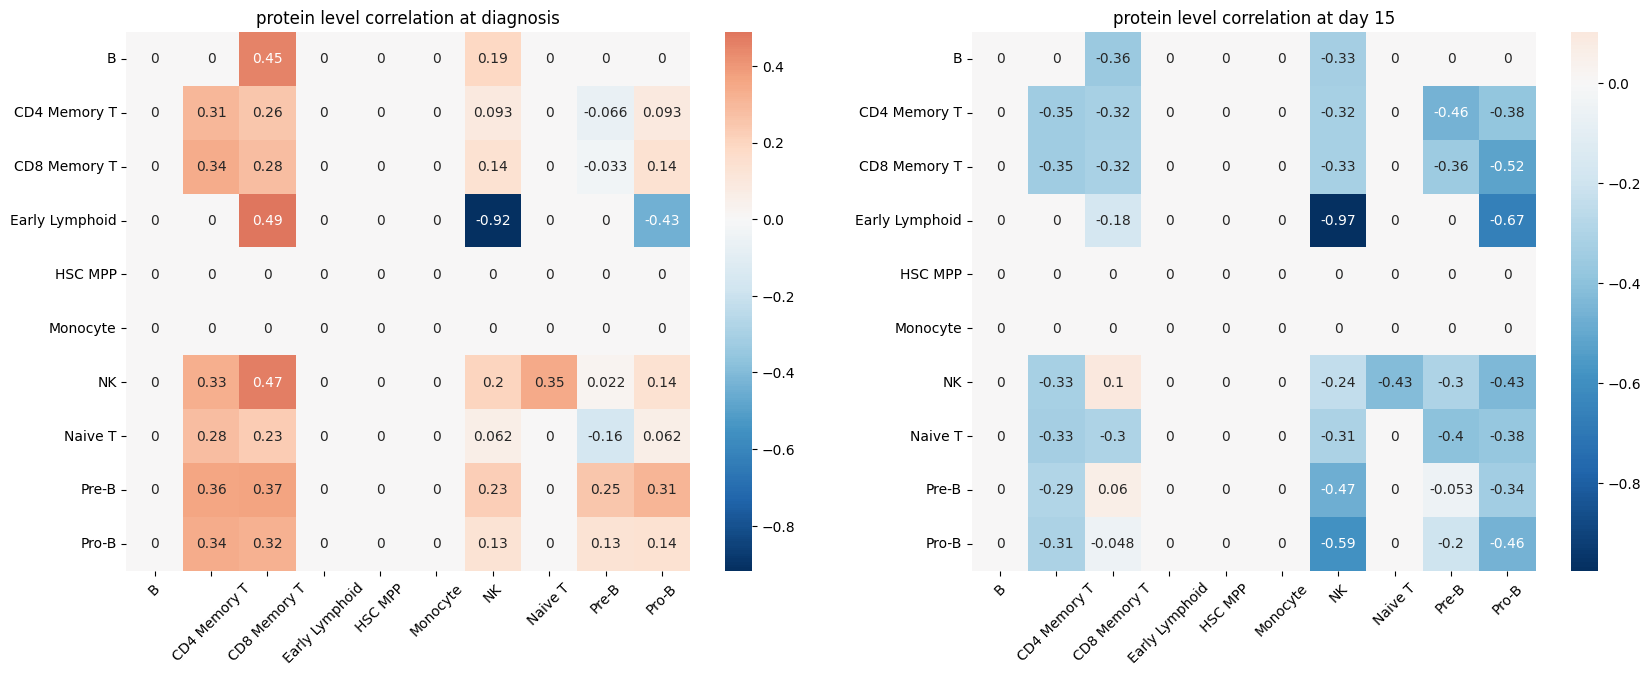

In [10]:
plt.figure(figsize=(9, 6))
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.heatmap(P_dg, cmap='RdBu_r',annot=True,ax = axes[0], center= 0)
sns.heatmap(p_d15, cmap='RdBu_r',annot=True,ax = axes[1], center=0)


axes[0].set_title('protein level correlation at diagnosis')
axes[1].set_title('protein level correlation at day 15')

axes[0].set_xticklabels(celltypes, rotation = 45)
axes[1].set_xticklabels(celltypes, rotation = 45)

axes[0].set_yticklabels(celltypes, rotation = 0)
axes[1].set_yticklabels(celltypes, rotation = 0)


In [11]:
X = W.index.values.reshape(-1, 1).astype(float)
Y = W[celltypes].values

In [12]:
X.dtype

dtype('float64')

In [13]:
prior

,souce,B,CD4 Memory T,CD8 Memory T,Early Lymphoid,HSC MPP,Monocyte,NK,Naive T,Plasma Cell,Pre-B,Pro-B
0,B,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,CD4 Memory T,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
2,CD8 Memory T,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
3,Early Lymphoid,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,HSC MPP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Monocyte,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,NK,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
7,Naive T,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
8,Plasma Cell,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,Pre-B,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0


In [14]:
prior = prior.reset_index(drop=True).drop(columns=['souce', 'Plasma Cell'])
prior = prior.drop(index=8)

In [15]:
print(prior)

      B  CD4 Memory T  CD8 Memory T  Early Lymphoid  HSC MPP  Monocyte   NK  \
0   0.0           0.0           1.0             0.0      0.0       0.0  1.0   
1   0.0           1.0           1.0             0.0      0.0       0.0  1.0   
2   0.0           1.0           1.0             0.0      0.0       0.0  1.0   
3   0.0           0.0           1.0             0.0      0.0       0.0  1.0   
4   0.0           0.0           0.0             0.0      0.0       0.0  0.0   
5   0.0           0.0           0.0             0.0      0.0       0.0  0.0   
6   0.0           1.0           1.0             0.0      0.0       0.0  1.0   
7   0.0           1.0           1.0             0.0      0.0       0.0  1.0   
9   0.0           1.0           1.0             0.0      0.0       0.0  1.0   
10  0.0           1.0           1.0             0.0      0.0       0.0  1.0   

    Naive T  Pre-B  Pro-B  
0       0.0    0.0    0.0  
1       0.0    1.0    1.0  
2       0.0    1.0    1.0  
3       0.0    0.0

Text(0.5, 1.02, 'Interaction prior variances based on receptor-ligand expression')

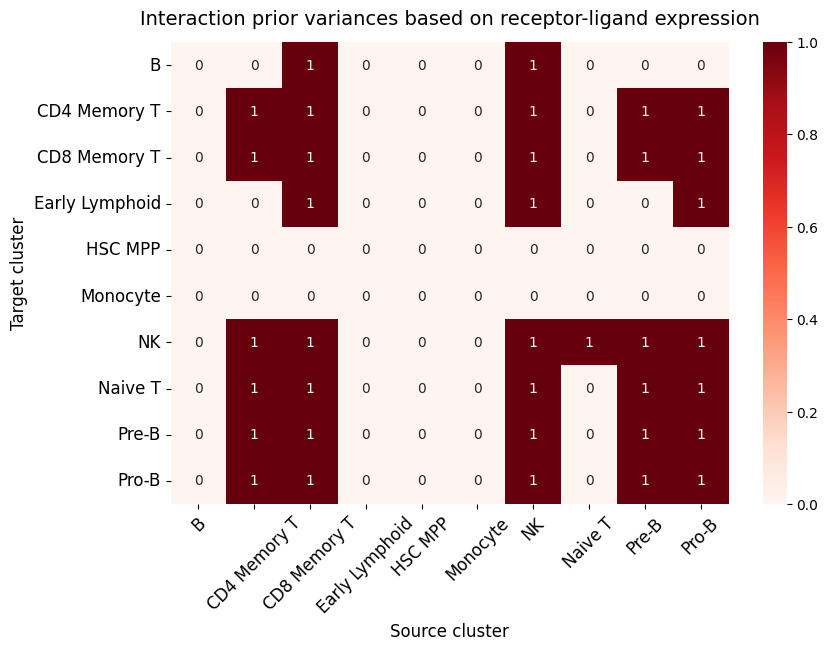

In [16]:
W_prior = np.array(prior)
plt.figure(figsize=(9, 6))
ax = sns.heatmap(prior, cmap="Reds", annot=True)
ax.set_yticklabels(celltypes, fontsize=12, rotation=0)
ax.set_xticklabels(celltypes, fontsize=12, rotation=45)
plt.xlabel('Source cluster', fontsize=12)
plt.ylabel('Target cluster', fontsize=12)
plt.title('Interaction prior variances based on receptor-ligand expression', 
          fontsize=14, y=1.02)

In [17]:

timepoints = torch.tensor(X)
proportions = torch.tensor(Y)
levels = torch.tensor(P_t)
prior_matrix = torch.tensor(prior.values)
n_timepoints, n_cell_types = proportions.shape

print('timepoints.shape:', timepoints.shape)
print('cell_types.shape:', proportions.shape)

timepoints.shape: torch.Size([2, 1])
cell_types.shape: torch.Size([2, 10])


In [18]:
proportions_mean = proportions.mean(dim=0)
proportions_std = proportions.std(dim=0)
proportions = (proportions - proportions_mean) / (proportions_std)

def unscale(proportions, proportions_mean, proportions_std, cluster_index): 
    return np.clip(proportions * 
                   proportions_std.detach().numpy()[cluster_index] + 
                   proportions_mean.detach().numpy()[cluster_index], 
                   0, None)

In [19]:
# lengthscale_f = np.mean(np.abs(X - X.T))
# lengthscale_f

# j = prior.sum(axis=1).max()
# lengthscale_W = max([X[i, 0] - X[i-j+1, 0] 
#                      for i in range(j-1, X.shape[0])])
# lengthscale_W

In [20]:
import diisco.names as names
hyperparams = {
    names.LENGTHSCALE_F: 6.5,
    names.LENGTHSCALE_W: 6.5,
    names.SIGMA_F: 0.5,
    names.VARIANCE_F: 1,
    names.SIGMA_W: 0.1,
    names.VARIANCE_W: 1,
    names.SIGMA_Y: 0.5,
}

In [21]:
timepoints

tensor([[ 0.],
        [15.]], dtype=torch.float64)

In [22]:
torch.set_default_dtype(torch.float64)

In [23]:
from diisco import DIISCO
model = DIISCO(lambda_matrix=prior_matrix, hypers_init_vals=hyperparams, verbose=True)
model.fit(timepoints, 
          proportions,
          levels= levels,
          n_iter=30000, 
          lr=0.00005,
          hypers_to_optim=[], 
          guide="MultivariateNormal")

[iteration 0001] loss: 27479.3944
[iteration 0101] loss: 25115.8084
[iteration 0201] loss: 26100.4485
[iteration 0301] loss: 21295.0696
[iteration 0401] loss: 22410.6938
[iteration 0501] loss: 23365.8552
[iteration 0601] loss: 19740.6977
[iteration 0701] loss: 22567.4953
[iteration 0801] loss: 21447.9666
[iteration 0901] loss: 20436.9418
[iteration 1001] loss: 21128.7632
[iteration 1101] loss: 17858.5339
[iteration 1201] loss: 19655.6338
[iteration 1301] loss: 17724.4506
[iteration 1401] loss: 16955.4155
[iteration 1501] loss: 18749.1930
[iteration 1601] loss: 15944.4531
[iteration 1701] loss: 17642.7723
[iteration 1801] loss: 16697.7524
[iteration 1901] loss: 15619.2164
[iteration 2001] loss: 16428.9160
[iteration 2101] loss: 16000.4782
[iteration 2201] loss: 14410.1374
[iteration 2301] loss: 16544.0509
[iteration 2401] loss: 15064.2712
[iteration 2501] loss: 17550.7911
[iteration 2601] loss: 13930.9017
[iteration 2701] loss: 12785.1833
[iteration 2801] loss: 12267.4856
[iteration 290

In [24]:
def unscale(proportions, cluster_index): 
    return np.clip(proportions * 
                   proportions_std.detach().numpy()[cluster_index] + 
                   proportions_mean.detach().numpy()[cluster_index], 
                   0, None)

Text(0.5, 1.05, 'DIISCO y samples')

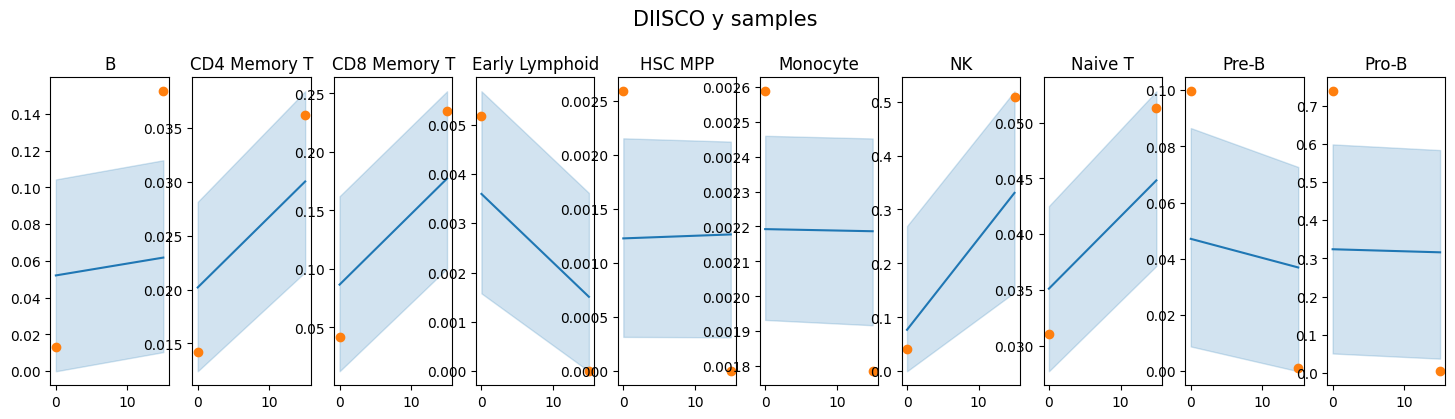

In [25]:
y = model.sample_observed_proportions(n_samples=1000).detach()

fig, axes = plt.subplots(1, n_cell_types, figsize=(18, 4))
for i in range(n_cell_types):
    cell_type_samples = y[:, :, i]
    mean = unscale(cell_type_samples.mean(axis=0), i)
    percentile_75 = unscale(np.percentile(cell_type_samples, 84, axis=0), i)
    percentile_25 = unscale(np.percentile(cell_type_samples, 16, axis=0), i)
    axes[i].plot(timepoints, mean, c='tab:blue')
    axes[i].fill_between(timepoints.squeeze(), percentile_25, percentile_75, color='tab:blue', alpha=0.2)
    axes[i].scatter(timepoints, unscale(proportions[:, i], i), c='tab:orange')
    axes[i].set_title(celltypes[i])

plt.suptitle('DIISCO y samples', fontsize=15, y=1.05)

In [26]:
import diisco

In [27]:
predict_timepoints = torch.linspace(timepoints.min(), timepoints.max(), 100).reshape(-1, 1)
samples = model.sample(predict_timepoints, 
                       n_samples=10000, 
                       n_samples_per_latent=10,
                       include_emission_variance=True)

100%|██████████| 10000/10000 [02:08<00:00, 77.79it/s]


In [28]:
W_samples_predict = samples['W']
f_samples_predict = samples['F']
y_samples_predict = samples['Y']

Text(0.5, 1.05, 'DIISCO predicted interactions ($\\hat{W}_{avg})$')

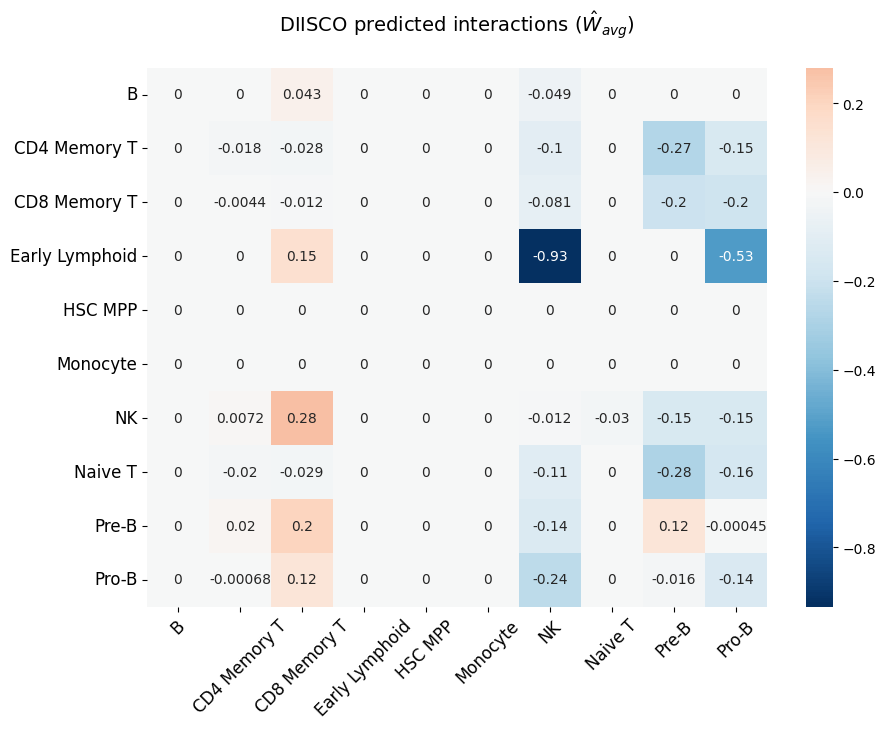

In [29]:
plt.figure(figsize=(10, 7))
W_avg_over_time = W_samples_predict.mean(axis=(0, 1)).detach().numpy()
ax = sns.heatmap(W_avg_over_time, cmap="RdBu_r", annot=True, 
                 center=0)
ax.set_yticklabels(celltypes, fontsize=12)
ax.set_xticklabels(celltypes, fontsize=12)
plt.yticks(rotation=0)
plt.xticks(rotation=45)
plt.title('DIISCO predicted interactions ($\hat{W}_{avg})$', fontsize=14, y=1.05)

In [30]:
W_avg_edge_list = []

for row in range(W_avg_over_time.shape[0]):
    for col in range(W_avg_over_time.shape[0]):
        W_avg_edge_list.append({
            'source': celltypes[col],
            'target': celltypes[row],
            'Interaction weight': W_avg_over_time[row, col],
            'abs(Interaction weight)': np.abs(W_avg_over_time[row, col]),
            'sign(Interaction weight)': np.sign(W_avg_over_time[row, col])
        })

W_avg_edge_list_df = pd.DataFrame(W_avg_edge_list)
W_avg_edge_list_df = W_avg_edge_list_df[W_avg_edge_list_df['source'] != W_avg_edge_list_df['target']]

In [31]:
W_avg = W_avg_edge_list_df.drop(W_avg_edge_list_df[W_avg_edge_list_df["Interaction weight"]==0].index,axis=0)
print(W_avg["Interaction weight"].to_list())

[0.043373650027081066, -0.049378292701616366, -0.02751282039975914, -0.10052232217991616, -0.27159621269484885, -0.15091169648967276, -0.0044194647683167875, -0.08139176146274203, -0.19977881950376425, -0.19719050197038626, 0.14789650231601514, -0.933324599242071, -0.5263166018508176, 0.007161550176544366, 0.2803721150372784, -0.030405832248851804, -0.14740140591111392, -0.1538049187695138, -0.02037269297277841, -0.028973469216961773, -0.10916052885976495, -0.28410423153863346, -0.16280194754629107, 0.019525637135003708, 0.20279937711153417, -0.13588264759148413, -0.00044886871974735937, -0.0006754643318649982, 0.11870903742352848, -0.24261139351104927, -0.015679660142761054]


In [32]:
Y[1]

array([0.15225708, 0.03621525, 0.23463402, 0.        , 0.        ,
       0.00178526, 0.50930885, 0.05126243, 0.00102015, 0.00433563])

[ 0.13932047  0.02198498  0.19323687 -0.00517464  0.4679117   0.02021457
 -0.09859175 -0.73305118]
[0.4771101502978917, -0.54316121971778, -0.1962385958630397, -0.3026410243973505, -1.1057455439790778, -2.9875583396433374, -1.6600286613864004, -0.04861411245148466, -0.13009584599241725, -0.8953093760901624, -2.1975670145414066, -2.1690955216742487, 1.6268615254761665, -10.26657059166278, -5.789482620358994, 0.07877705194198803, 3.084093265410062, -0.13300857648977407, -0.33446415473736985, -1.6214154650222532, -1.6918541064646517, -0.22409962270056252, -0.3187081613865795, -1.2007658174574145, -3.125146546924968, -1.7908214230092017, 0.21478200848504078, 2.230793148226876, -1.4947091235063255, 1.292404373926867, -0.004937555917220953, -0.0074301076505149805, 1.3057994116588132, -2.6687253286215418, -0.1724762615703716, -1.5656827992263158]
['orange', 'lightblue', 'lightblue', 'lightblue', 'lightblue', 'lightblue', 'lightblue', 'lightblue', 'lightblue', 'lightblue', 'lightblue', 'lightb

(np.float64(-1.2099999418216294),
 np.float64(1.2099999944717386),
 np.float64(-1.2153246249613068),
 np.float64(1.3218181655791625))

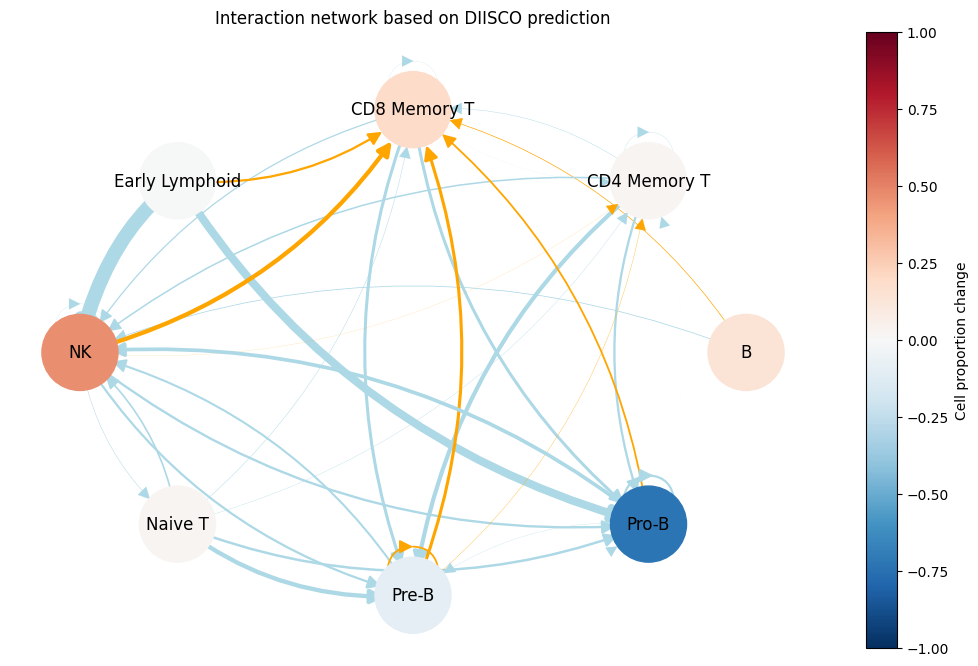

In [33]:
from matplotlib.colors import TwoSlopeNorm
y_predict = pd.DataFrame(y_samples_predict.mean(axis=0))
y_change = (Y[1] - Y[0])

positions_list = {i: celltypes[i] for i in range(len(celltypes))}

G = nx.MultiDiGraph()
n_cell_types = W_avg_over_time.shape[0]

# add nodes with predicted y

for k in range(n_cell_types):
    G.add_node(k, delta=float(y_change[k]))
    G.nodes[k]['mag'] = float(abs(y_change[k]))


# add edges weighted by contribution
for i in range(n_cell_types):
    for j in range(n_cell_types):
        weight = W_avg_over_time[i,j]
        if abs(weight) !=0:
            G.add_edge(i, j, weight=weight) 


nodes_to_remove = [n for n in G.nodes if G.degree(n) == 0]
G.remove_nodes_from(nodes_to_remove)

pos = nx.circular_layout(G)

nodelist = list(G.nodes)
node_delta = np.array([float(G.nodes[n].get('delta', 0.0)) for n in nodelist], dtype=float) # signed
print(node_delta)
node_mag   = np.array([G.nodes[n]['mag']   for n in nodelist], dtype=float)

norm = TwoSlopeNorm(vmin=-1, vcenter=0.0, vmax=1)


edges = list(G.edges(keys=True, data=True))
edge_weights = [float(d.get('weight', 0)) * 11 for (_, _, _, d) in edges]

edge_colors = ['orange' if d.get('weight', 0) > 0 else 'lightblue' for (_, _, _, d) in edges]
print(edge_weights)
print(edge_colors)
fig, ax = plt.subplots(figsize=(13, 8))
nx.draw(G,
        pos,
        nodelist=nodelist,
        node_size=3000,
        node_color=node_delta, 
        cmap=plt.cm.RdBu_r,
        vmin=-1,
        vmax=1,
        labels={n: positions_list[n] for n in G.nodes if n in positions_list},
        edgelist=[(u, v, k) for (u, v, k, _) in edges],
        width = edge_weights,
        edge_color=edge_colors,
        arrows=True,
        arrowsize=20,
        connectionstyle='arc3,rad=0.2')


sm = plt.cm.ScalarMappable(cmap=plt.cm.RdBu_r, norm=norm)
sm.set_array([])
fig.colorbar(sm,ax=ax).set_label('Cell proportion change')

plt.title("Interaction network based on DIISCO prediction")
plt.axis('off')

In [34]:
W_avg_edge_list_df.to_csv('/research/groups/bioinformaticians/internship/hhuotari/DIISCO/data/EG11_16_res.csv')

OSError: Cannot save file into a non-existent directory: '\research\groups\bioinformaticians\internship\hhuotari\DIISCO\data'

### With online version of Cytoscape: <br>
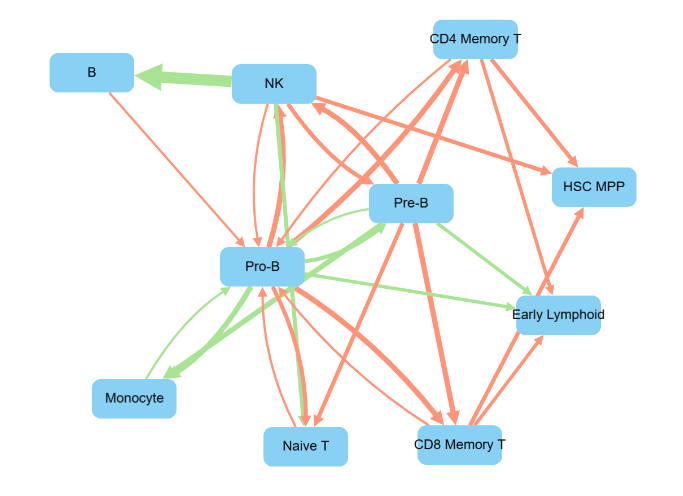 <br>
<br>
Here the target is where the arrow ends and scource where it starts. The wights are based on the edge weight calculated from W_avg